In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# =========================
# System parameters
# =========================
alpha = 1.0       # linear stiffness
beta = 1.0        # hardening nonlinearity
delta = 0.02      # damping
omega = 0.9       # forcing frequency

# =========================
# Simulation parameters
# =========================
n_periods_total = 2000     # total periods
n_periods_keep  = 200      # last periods to keep
points_per_period = 200    # time resolution

T = 2 * np.pi / omega
dt = T / points_per_period

# =========================
# Duffing ODE
# =========================
def duffing(t, y, gamma):
	x, v = y
	dxdt = v
	dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
	return [dxdt, dvdt]

# =========================
# Single gamma simulation
# =========================
def simulate_gamma(gamma, store_full_history=False):
	t_span = (0, n_periods_total * T)
	t_eval = np.arange(0, t_span[1], dt)

	sol = solve_ivp(
		duffing,
		t_span,
		y0=[0.1, 0.0],
		t_eval=t_eval,
		args=(gamma,),
		method='RK45',
		rtol=1e-6,
		atol=1e-9
	)

	x = sol.y[0]
	xdot = sol.y[1]
	t = sol.t

	# Stroboscopic sampling at one point per forcing period.
	strobe_indices = np.arange(0, len(t), points_per_period)
	t_strobe = t[strobe_indices]
	x_strobe = x[strobe_indices]
	xdot_strobe = xdot[strobe_indices]

	# Discard transient for the Poincaré map.
	t_strobe_ss = t_strobe[-n_periods_keep:]
	x_ss = x_strobe[-n_periods_keep:]
	xdot_ss = xdot_strobe[-n_periods_keep:]

	result = {
		"gamma": gamma,
		"t_strobe": t_strobe_ss,
		"x_poincare": x_ss,
		"xdot_poincare": xdot_ss,
	}

	if store_full_history:
		result.update({
			"t": t,
			"x": x,
			"xdot": xdot,
		})

	return result

# =========================
# Parameter sweep (parallel)
# =========================
gamma_values = np.linspace(0.2, 60, 200)

poincare_results = Parallel(n_jobs=-1, verbose=10)(
	delayed(simulate_gamma)(g, store_full_history=False) for g in gamma_values
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   40.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed: 12.5min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed: 14.9min
[Parallel(n_jobs=-1)]: Done 190 out of 200 | elapsed: 16.9min remaining:   53.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 18.0min finished


In [6]:

# =========================
# Collect results
# =========================
gamma_all = np.concatenate([np.full_like(r["x_poincare"], r["gamma"], dtype=float) for r in poincare_results])
x_all = np.concatenate([r["x_poincare"] for r in poincare_results])
xdot_all = np.concatenate([r["xdot_poincare"] for r in poincare_results])

# =========================
# Save full time histories for selected amplitudes
# =========================
phase_gamma_targets = [2.0, 10.0, 25.0, 30, 45.0 ,60]
phase_histories = {}

for gamma_target in phase_gamma_targets:
	gamma_actual = float(gamma_values[np.argmin(np.abs(gamma_values - gamma_target))])
	if gamma_actual not in phase_histories:
		phase_histories[gamma_actual] = simulate_gamma(gamma_actual, store_full_history=True)


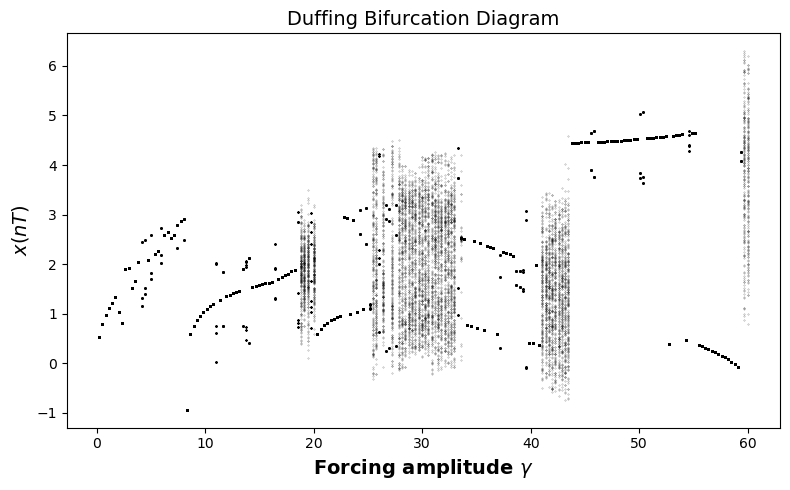

In [7]:
# =========================
# Plot 1: bifurcation diagram
# =========================
plt.figure(figsize=(8, 5))
plt.plot(gamma_all, x_all, '.k', alpha=0.5, markersize=0.5)

plt.xlabel(r'Forcing amplitude $\gamma$', fontsize=14, fontweight='bold')
plt.ylabel(r'$x(nT)$', fontsize=14, fontweight='bold')
plt.title('Duffing Bifurcation Diagram', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()


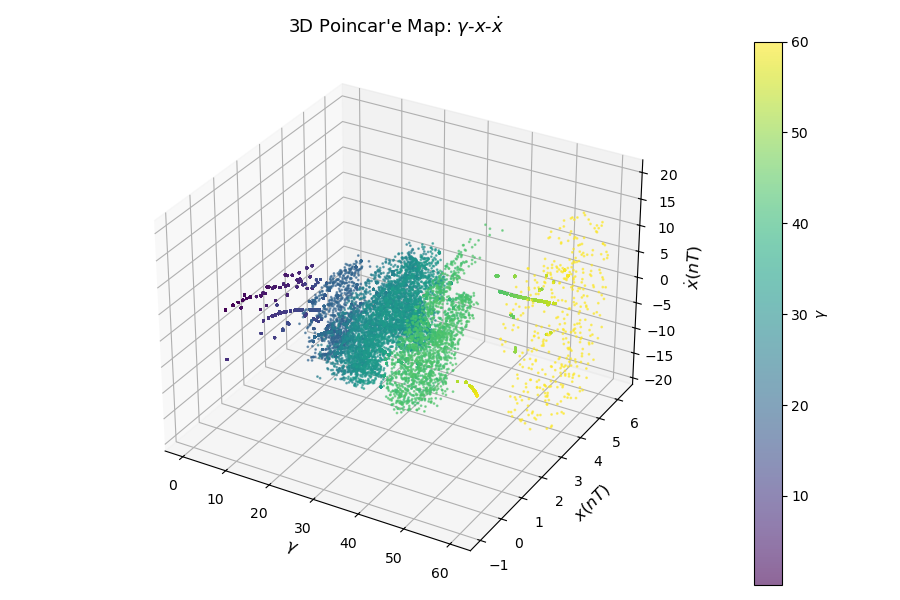

In [9]:
%matplotlib widget
# =========================
# Plot 2: 3D Poincaré map
# =========================
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(gamma_all, x_all, xdot_all, c=gamma_all, cmap='viridis', s=1, alpha=0.6)

ax.set_xlabel(r'$\gamma$', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$x(nT)$', fontsize=12, fontweight='bold')
ax.set_zlabel(r'$\dot{x}(nT)$', fontsize=12, fontweight='bold')
ax.set_title('3D Poincar\'e Map: $\gamma$-$x$-$\dot{x}$', fontsize=13)
fig.colorbar(sc, ax=ax, pad=0.1, label=r'$\gamma$')
plt.tight_layout()
plt.show()


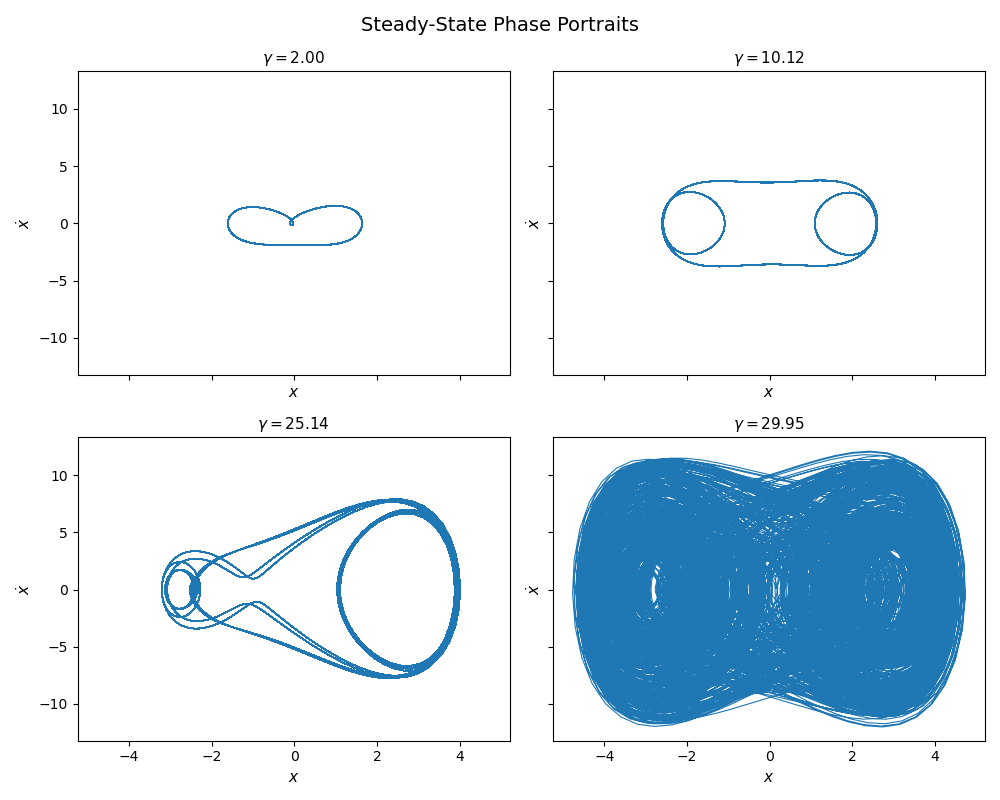

In [10]:

# =========================
# Plot 3: phase portraits at selected amplitudes
# =========================
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (gamma_actual, hist) in zip(axes, phase_histories.items()):
	start_index = -n_periods_keep * points_per_period
	x_phase = hist["x"][start_index:]
	xdot_phase = hist["xdot"][start_index:]
	ax.plot(x_phase, xdot_phase, lw=0.8)
	ax.set_title(rf'$\gamma = {gamma_actual:.2f}$', fontsize=11)
	ax.set_xlabel(r'$x$', fontsize=11)
	ax.set_ylabel(r'$\dot{x}$', fontsize=11)
	ax.grid(False)

for ax in axes[len(phase_histories):]:
	ax.axis('off')

fig.suptitle('Steady-State Phase Portraits', fontsize=14)
plt.tight_layout()
plt.show()